In [1]:
from nepse import AsyncNepse 
import asyncio,time,requests
import pandas as pd
import datetime
from io import StringIO as sio
import os
import glob
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
nepse = AsyncNepse()
nepse.setTLSVerification(False)  # Temporary, until NEPSE sorts its SSL certificate problem

In [3]:
df=pd.read_json(r'files\2025\2025-05-07.json')
# df['id']=df['marketDepth'][0].get('buyMarketDepthList')[0].get('stockId')
df_combined = pd.DataFrame()
for i in df.index:
    df1 = pd.DataFrame.from_dict(df['data'][i]).T[['totalBuyQty', 'totalSellQty']]
    df1['timestamp'] = df['timestamp'][i]
    df1.reset_index(inplace=True)
    if df_combined.empty:
        df_combined = df1
    else:
        df_combined = pd.concat([df_combined, df1])

df_combined=pd.merge(df_combined, pd.DataFrame.from_dict(await nepse.getCompanyList())[['symbol', 'sectorName']], left_on='index',right_on='symbol', how='left')
pd.set_option('future.no_silent_downcasting', True)#to be future proof as on march 2025
df_combined[['totalBuyQty', 'totalSellQty']] = df_combined[['totalBuyQty', 'totalSellQty']].replace(0, 1)

# Sample dataframe (replace with your actual data loading)
df_md=df_combined.copy()
# Group by 'symbol' and 'sectorName', summing quantities
df_agg = df_md.groupby(['symbol','sectorName']).agg({
    'totalBuyQty': 'sum',
    'totalSellQty': 'sum'
}).reset_index()

# Compute imbalance
df_agg['imbalance'] = (df_agg['totalBuyQty'] - df_agg['totalSellQty']) / (df_agg['totalBuyQty'] + df_agg['totalSellQty'])

# Sort by imbalance to identify scripts with high buying interest
df_sorted = df_agg.sort_values(by='imbalance', ascending=False)
df_sorted.to_clipboard(index=False)

In [4]:
folder_path=Path(r'files\2025')
df_sorted_c=pd.DataFrame()
for file_path in sorted(folder_path.glob("*.json")):
    # Extract date from filename (assuming format is yyyy-mm-dd.json)
    file_date_str = file_path.stem  # Gets filename without extension
    try:
        file_date = datetime.datetime.strptime(file_date_str, "%Y-%m-%d")
        if file_date > datetime.datetime.strptime('2025-03-25', "%Y-%m-%d"):
            print(f"Processing: {file_path}")
            df=pd.read_json(file_path)
            df_combined = pd.DataFrame()
            for i in df.index:
                df1 = pd.DataFrame.from_dict(df['data'][i]).T[['totalBuyQty', 'totalSellQty']]
                df1['timestamp'] = df['timestamp'][i]
                df1.reset_index(inplace=True)
                if df_combined.empty:
                    df_combined = df1
                else:
                    df_combined = pd.concat([df_combined, df1])

            df_combined=pd.merge(df_combined, pd.DataFrame.from_dict(await nepse.getCompanyList())[['symbol', 'sectorName']], left_on='index',right_on='symbol', how='left')
            pd.set_option('future.no_silent_downcasting', True)#to be future proof as on march 2025
            df_combined[['totalBuyQty', 'totalSellQty']] = df_combined[['totalBuyQty', 'totalSellQty']].replace(0, 1)

            # Sample dataframe (replace with your actual data loading)
            df_md=df_combined.copy()
            # Group by 'symbol' and 'sectorName', summing quantities
            df_agg = df_md.groupby(['symbol','sectorName']).agg({
                'totalBuyQty': 'sum',
                'totalSellQty': 'sum'
            }).reset_index()

            # Compute imbalance
            df_agg['imbalance'] = (df_agg['totalBuyQty'] - df_agg['totalSellQty']) / (df_agg['totalBuyQty'] + df_agg['totalSellQty'])
            df_agg['date']=file_date_str

            # Sort by imbalance to identify scripts with high buying interest
            df_sorted = df_agg.sort_values(by=['date', 'imbalance'], ascending=False)
            df_sorted_c = pd.concat([df_sorted_c, df_sorted])
            df_sorted_c.to_clipboard(index=False)

    except ValueError:
        # Skip files that don't match the date format
        continue


Processing: files\2025\2025-03-26.json
Processing: files\2025\2025-03-27.json
Processing: files\2025\2025-03-30.json
Processing: files\2025\2025-03-31.json
Processing: files\2025\2025-04-01.json
Processing: files\2025\2025-04-02.json
Processing: files\2025\2025-04-03.json
Processing: files\2025\2025-04-06.json
Processing: files\2025\2025-04-07.json
Processing: files\2025\2025-04-08.json
Processing: files\2025\2025-04-09.json
Processing: files\2025\2025-04-10.json
Processing: files\2025\2025-04-13.json
Processing: files\2025\2025-04-14.json
Processing: files\2025\2025-04-15.json
Processing: files\2025\2025-04-16.json
Processing: files\2025\2025-04-17.json
Processing: files\2025\2025-04-20.json
Processing: files\2025\2025-04-21.json
Processing: files\2025\2025-04-22.json
Processing: files\2025\2025-04-23.json
Processing: files\2025\2025-04-24.json
Processing: files\2025\2025-04-27.json
Processing: files\2025\2025-04-28.json
Processing: files\2025\2025-04-29.json
Processing: files\2025\20

In [5]:
df_sorted_c = df_sorted_c.sort_values(by=['symbol', 'date'])
n_days=5  
# Define the rolling window size (number of days)

df_sorted_c['rolling_imbalance'] = (
    df_sorted_c.groupby('symbol')['imbalance']
    .rolling(window=n_days, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)
df_sorted_c.to_clipboard(index=False)

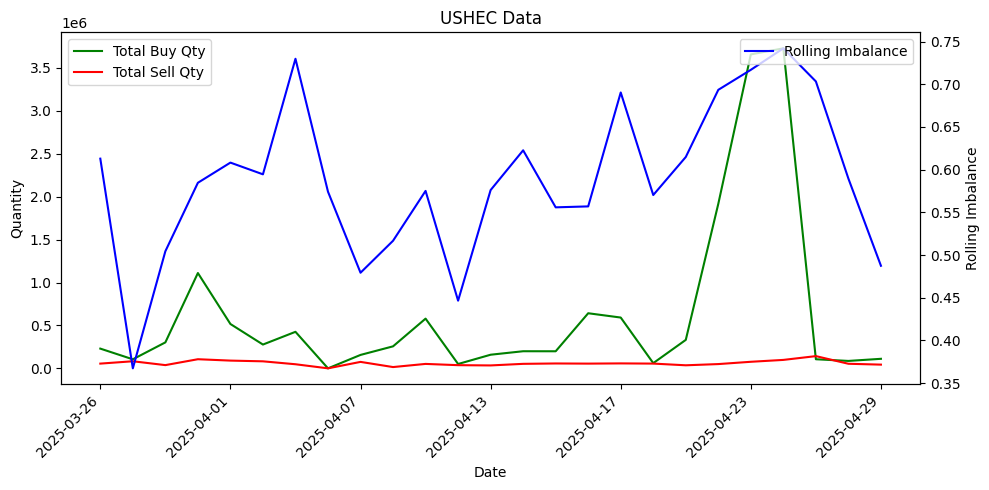

In [18]:
scriptname="USHEC"
# Assuming df_sorted_c is your DataFrame and has the required columns
fig, ax1 = plt.subplots(figsize=(10, 5))
scriptwise = df_sorted_c[df_sorted_c["symbol"]==scriptname]
# Plot totalBuyQty and totalSellQty on the left y-axis
ax1.plot(scriptwise["date"], 
         scriptwise["totalBuyQty"], 
         label="Total Buy Qty", color="green")
ax1.plot(scriptwise["date"], 
         scriptwise["totalSellQty"], 
         label="Total Sell Qty", color="red")

# Set labels for left y-axis
ax1.set_xlabel("Date")
ax1.set_ylabel("Quantity")
ax1.legend(loc="upper left")

# Create a second y-axis for rolling_imbalance
ax2 = ax1.twinx()
ax2.plot(scriptwise["date"], 
         scriptwise["rolling_imbalance"], 
         label="Rolling Imbalance", color="blue")

# Set labels for right y-axis
ax2.set_ylabel("Rolling Imbalance")
ax2.legend(loc="upper right")

# Set the title
plt.title(f"{scriptname} Data")

ax1.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5, maxticks=10))  # Limit number of ticks

plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

fig.tight_layout()

# Show the plot
plt.show()

In [53]:
chart_provider={
'nepsechart':'https://ohlcv.nepsechart.com/history?symbol={symbol}&resolution={resolution}&from={fromtime}&to={totime}',
'merocapital':'https://chartdata.merocapital.com/datafeed1/history?symbol={symbol}&resolution={resolution}&from={fromtime}&to={totime}',
'merolaganida':'https://da.merolagani.com/handlers/TechnicalChartHandler.ashx?type=get_advanced_chart&symbol={symbol}&resolution={resolution}&rangeStartDate={fromtime}&rangeEndDate={totime}&from=&isAdjust=1&currencyCode=NPR',
'merolagani':'https://www.merolagani.com/handlers/TechnicalChartHandler.ashx?type=get_advanced_chart&symbol={symbol}&resolution={resolution}&rangeStartDate={fromtime}&rangeEndDate={totime}&from=&isAdjust=1&currencyCode=NPR',
'nepsealpha':'https://nepsealpha.com/trading/1/history?symbol={symbol}&resolution={resolution}&from={fromtime}&to={totime}&pass=ok&force=261651&currencyCode=NRS',
'nepsedata':'https://nepsedata.com/history?symbol={symbol}&resolution={resolution}&from={fromtime}&to={totime}&currencyCode=NRS'
}
def chart_data(symbol="NEPSE",provider='merolagani',fromtime=datetime.date(2022,6,1),totime=datetime.datetime.now(),resolution="1D"):
    """returns data fetched from nepsealpha,merocapital,merolagani and nepsechart.\nwarning!! \nNepsechart,merocapital takes D for daily resolution.\nMerocapital,nepsedata gives unadjusted chart)"""
    fromtime =int(time.mktime(fromtime.timetuple()))
    totime =int(time.mktime(totime.timetuple()))
    url=chart_provider.get(provider)
    df=pd.read_json(sio(requests.get(url.format(symbol=symbol,resolution=resolution,fromtime=fromtime,totime=totime)).text))
    df['t']=df['t'].apply(datetime.datetime.utcfromtimestamp)
    df.drop('s',axis=1,inplace=True)
    return df

In [54]:
chart_data("NBL")

,t,o,h,l,c,v
0,2022-05-31 20:45:00,290.29,294.31,290.29,292.16,45100
1,2022-06-01 20:45:00,297.06,297.06,288.92,293.14,30125
2,2022-06-02 20:45:00,290.20,296.96,290.20,292.16,33731
3,2022-06-03 20:45:00,292.16,293.14,286.27,288.24,48065
4,2022-06-06 20:45:00,292.16,295.10,284.31,289.02,35938
...,...,...,...,...,...,...
664,2025-04-01 20:44:30,252.00,252.00,246.40,248.77,74403
665,2025-04-02 20:44:45,253.70,253.70,246.00,249.99,212077
666,2025-04-03 20:44:38,250.00,256.00,248.00,251.30,62089
667,2025-04-07 20:44:58,251.30,255.00,247.00,247.23,59446


In [ ]:
# Sample OHLC data (replace with your actual data)
ohlc_data = {
    'symbol': ['USHL', 'ACLBSL', 'ACLBSLP', 'ANLB'],
    'date': ['2023-10-01', '2023-10-01', '2023-10-01', '2023-10-01'],
    'open': [100, 150, 200, 50],
    'close': [102, 148, 201, 49]
}
df_ohlc = pd.DataFrame(ohlc_data)

# Merge market depth aggregated data with OHLC
df_merged = pd.merge(df_agg, df_ohlc, on='symbol')

# Compute daily return
df_merged['return'] = (df_merged['close'] - df_merged['open']) / df_merged['open']

# Check correlation
correlation = df_merged['imbalance'].corr(df_merged['return'])
print(f"Correlation between Imbalance and Return: {correlation}")

# Scatter plot
import matplotlib.pyplot as plt
plt.scatter(df_merged['imbalance'], df_merged['return'])
plt.xlabel('Imbalance (Buy/Sell)')
plt.ylabel('Daily Return')
plt.title('Imbalance vs. Price Return')
plt.show()

In [46]:
# Individual Script Market Depth

pos=7
script="NMIC"

dict=df.iloc[pos]['data'][script]
df1=pd.DataFrame.from_dict(dict["marketDepth"]["buyMarketDepthList"])
print(df1)

df2=pd.DataFrame.from_dict(dict["marketDepth"]["sellMarketDepthList"])
print(df2)

pd.DataFrame.from_dict(dict)


   stockId  orderBookOrderPrice  quantity  orderCount  isBuy   buy   sell
0     9250                365.7   2095868       11271      1  True  False
1     9250                365.6     26266         220      1  True  False
2     9250                365.5      9927         163      1  True  False
3     9250                365.4      3111          66      1  True  False
4     9250                365.3      2805          67      1  True  False
   stockId  orderBookOrderPrice  quantity  orderCount  isBuy    buy  sell
0     9250                  0.0         0           0      2  False  True
1     9250                  0.0         0           0      2  False  True
2     9250                  0.0         0           0      2  False  True
3     9250                  0.0         0           0      2  False  True
4     9250                  0.0         0           0      2  False  True


,totalBuyQty,marketDepth,totalSellQty
buyMarketDepthList,2492605,"[{'stockId': 9250, 'orderBookOrderPrice': 365....",0
sellMarketDepthList,2492605,"[{'stockId': 9250, 'orderBookOrderPrice': 0.0,...",0


In [3]:

# Initialize an empty DataFrame
df_combined = pd.DataFrame()

# Loop through each JSON file in the directory
for file in glob.glob(r'files\2025\*.json'):
    df_temp = pd.read_json(file)
    for i in range(len(df_temp['data'])):
        df1 = pd.DataFrame.from_dict(df_temp['data'][i]).T[['totalBuyQty', 'totalSellQty']]
        df1['timestamp'] = df_temp['timestamp'][i]
        df1.reset_index(inplace=True)
        if df_combined.empty:
            df_combined = df1
        else:
            df_combined = pd.concat([df_combined, df1])

# Assign the combined DataFrame to df2
df3 = df_combined

In [27]:
for i in range(len(df['data'])):
    df1=pd.DataFrame.from_dict(df['data'][i]).T[['totalBuyQty','totalSellQty']]
    df1['timestamp']=df['timestamp'][i]
    df1.reset_index(inplace=True)
    if i==0:
        df2=df1
    else:
        df2=pd.concat([df2,df1])

In [37]:
df2[df2['index']=='UPCL']

,index,totalBuyQty,totalSellQty,timestamp
466,UPCL,8210,700,2025-01-01 11:08:38.469359
466,UPCL,26211,1160,2025-01-01 11:25:13.886984
466,UPCL,39489,8230,2025-01-01 12:16:44.498276
466,UPCL,41212,8765,2025-01-01 12:31:21.399839
466,UPCL,45140,11354,2025-01-01 12:55:36.500189
466,UPCL,45673,12282,2025-01-01 13:17:21.609275
466,UPCL,46773,17285,2025-01-01 14:02:49.728837
466,UPCL,49913,14801,2025-01-01 14:29:05.596801
466,UPCL,49262,15555,2025-01-01 14:37:13.072795


In [42]:
def get_ohlc_data(df, script,qty_type):
    # Filter the dataframe for the given script
    script_data = df[df['index'] == script]

    # Ensure the data is sorted by timestamp
    script_data = script_data.sort_values(by='timestamp')

    # Get the OHLC data
    ohlc_data = {
        'open': script_data.iloc[0][qty_type],
        'high': script_data[qty_type].max(),
        'low': script_data[qty_type].min(),
        'close': script_data.iloc[-1][qty_type]
    }
    return ohlc_data

# Example usage
ohlc_data = get_ohlc_data(df2, 'UPCL','totalSellQty')
print(ohlc_data)

{'open': 700, 'high': 17285, 'low': 700, 'close': 15555}


<Axes: xlabel='timestamp'>

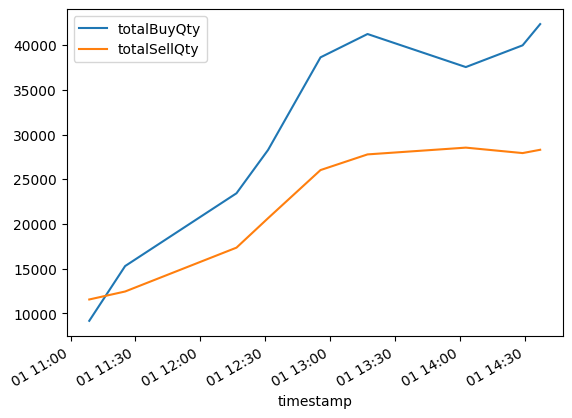

In [43]:
df2[df2['index']=='SHIVM'].plot(x='timestamp',y=['totalBuyQty','totalSellQty'])

In [20]:
df_sorted

,symbol,sectorName,totalBuyQty,totalSellQty,imbalance
221,NMIC,Non Life Insurance,13947353,7,0.999999
211,NLO,Manufacturing And Processing,759361,7,0.999982
213,NMB50,Mutual Fund,422400,7,0.999967
290,SFEF,Commercial Banks,1238800,106,0.999829
260,RMF2,Mutual Fund,2012610,2000,0.998015
...,...,...,...,...,...
283,SBLD84,Commercial Banks,7,35,-0.666667
193,NICAD8283,Commercial Banks,1810,11313,-0.724148
187,NIBD2082,Commercial Banks,7,79,-0.837209
29,C30MF,Commercial Banks,6154,87232,-0.868203


All Scripts Sorted by Imbalance:
        symbol                    sectorName totalBuyQty totalSellQty  \
221       NMIC            Non Life Insurance    13947353            7   
211        NLO  Manufacturing And Processing      759361            7   
213      NMB50                   Mutual Fund      422400            7   
290       SFEF              Commercial Banks     1238800          106   
260       RMF2                   Mutual Fund     2012610         2000   
..         ...                           ...         ...          ...   
283     SBLD84              Commercial Banks           7           35   
193  NICAD8283              Commercial Banks        1810        11313   
187   NIBD2082              Commercial Banks           7           79   
29       C30MF              Commercial Banks        6154        87232   
236     PBLD86              Commercial Banks           7         1575   

    imbalance  
221  0.999999  
211  0.999982  
213  0.999967  
290  0.999829  
260  0.998

TypeError: Column 'imbalance' has dtype object, cannot use method 'nlargest' with this dtype

In [21]:

pd.DataFrame.from_dict(await nepse.getCompanyList()).to_clipboard()

In [20]:
await nepse.getMarketStatus()

{'isOpen': 'CLOSE', 'asOf': '2024-12-26T15:00:00', 'id': 80}

In [9]:
pd.DataFrame.from_dict(df['data'][0])

ValueError: If using all scalar values, you must pass an index

In [3]:
datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

'2024-12-26_18-52-50'

In [6]:
from datetime import timedelta

adjusted_time = datetime.now() - timedelta(hours=5, minutes=45)
adjusted_time.strftime("%Y-%m-%d_%H-%M-%S")

'2024-12-26_13-39-34'

In [21]:
def get_id(dep_dict):
    if isinstance(dep_dict, dict) and 'buyMarketDepthList' in dep_dict:
        try:
            return dep_dict.get('buyMarketDepthList')[0].get('stockId')
        except (IndexError, AttributeError):
            return None  # Return None if the structure isn't as expected
    return None  # Return None for non-dictionaries or invalid inputs

In [38]:
pd.DataFrame.from_dict(await nepse.getCompanyList()).to_clipboard()

In [ ]:
adjusted_time = datetime.now() - pd.Timedelta(hours=5, minutes=45)
adjusted_time.strftime("%Y-%m-%d_%H-%M-%S")

In [2]:
nepse = AsyncNepse()
nepse.setTLSVerification(False)  # Temporary, until NEPSE sorts its SSL certificate problem

async def fetch_company_details():
    # Fetch the list of companies
    company_list = await nepse.getCompanyList()

    # Fetch details for each company concurrently
    tasks = [
        nepse.getCompanyDetails(company['symbol']) 
        for company in company_list 
        if company['status'] == 'A'
    ]

    company_details = await asyncio.gather(*tasks)

    # Combine company and details
    result = []
    for company, details in zip(company_list, company_details):
        # If details is a list, handle it appropriately
        if isinstance(details, list):
            # Add details as a key-value pair
            result.append({**company, "details": details})
        elif isinstance(details, dict):
            # Merge dictionaries directly
            result.append({**company, **details})
        else:
            # Handle unexpected formats (optional)
            result.append({**company, "details": str(details)})

    return result

In [28]:
df=pd.DataFrame.from_dict(await nepse.getSecurityList())

NameError: name 'nepse' is not defined

In [5]:
async def main():
    results = await fetch_company_details()

    # Ensure the "files/" directory exists
    os.makedirs("files", exist_ok=True)

    # Generate filename with timestamp
    now = datetime.now()
    filename = now.strftime("%Y-%m-%d_%H-%M-%S")
    pd.DataFrame.from_dict(results).to_excel(f"files/{filename}.xlsx", index=False)

# Execute the main function
# asyncio.run(main()) ## This is not working in Jupyter Notebook, but in py file it must be the function
await main()

c:\Users\Dell\AppData\Local\Programs\Python\Python311\Lib\asyncio\base_events.py:106: RuntimeWarning: coroutine 'main' was never awaited
  if proto not in {0, socket.IPPROTO_TCP, socket.IPPROTO_UDP} or \


In [105]:
# import plotly.graph_objects as go
# fig = go.Figure(data=go.Candlestick(x=demand_ohlc.reset_index()['a'],
#                     open=demand_ohlc['open'],
#                     high=demand_ohlc['high'],
#                     low=demand_ohlc['low'],
#                     close=demand_ohlc['close']))
# fig.show()